# Exploring conceptual model for Wahpeton Model 

This note book aims to test if we can get water in from the Otter tail river area into the Buried Valley aquifer so that the Buried Valley aquifer heads match the river stage in the Otter Tail area. 
To do this we force:
 1. vertical Ks to a high value in layers 1-3 in the area around Otter Tail
 2. confine vks in all other areas so that Buried Vallley stays confined every where else
 3. we remove the recharge package and ghbs because we are fully focused on the river/confied aquifer dynamics 

In [10]:
import os 
import sys
import shutil 
from datetime import datetime
sys.path.insert(0,os.path.abspath(os.path.join('..','..','..','dependencies')))
sys.path.insert(1,os.path.abspath(os.path.join('..','..','..','dependencies','flopy')))
sys.path.insert(2,os.path.abspath(os.path.join('..','..','..','dependencies','pyemu')))
import pyemu
import flopy
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import geopandas as gpd
from typing import Sequence, Union
import notebook_plotting as nplt


load clean modflow files adn run to make sure you are starting from a good place:

In [ ]:
run_tag = 'kv_1e-3'
test_case = f'test_case_{run_tag}'

# specify the KV you want to change layer 3 to in all areas except for the masked windows:
chng_kv = 1e-3 # prob should match tag label above to keep things organized

# orginal workspace:
ows = os.path.join('..','model_ws','wahp_clean')
# test case directory:
w_d = test_case

if os.path.exists(w_d):
    shutil.rmtree(w_d)
shutil.copytree(ows, w_d)

#pyemu.utils.run("mf6",cwd=w_d)

'test_case_kv_1e-4'

load sim and all gwf packages we want to modify:

In [12]:
sim = flopy.mf6.MFSimulation.load(sim_ws=w_d,version="mf6")
gwf = sim.get_model()

nrows = gwf.modelgrid.nrow
ncols = gwf.modelgrid.ncol
delr = gwf.modelgrid.delr[0]
id = gwf.dis.idomain.array
npf = gwf.npf


loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package riv...
    loading package drn...
    loading package rch...
    loading package ghb...
    loading package oc...
    loading package wel...
    loading package wel...
    loading package wel...
    loading package wel...
    loading package wel...
    loading package obs...
  loading solution package wahp...


load npf package and print out the inital Khs and Kv by layer.
*** Note model is homogenous in each layer ***

In [13]:
# npf
kh_files = [f for f in os.listdir(w_d) if f.startswith('npf_k_')]
kh_files.sort(key=lambda x: int(x.split('_')[2].split('.')[0].replace('layer','')))
init_kh = {}
for file in kh_files:
    kh = np.loadtxt(os.path.join(w_d, file))
    med_kh = np.median(kh)
    ly = int(file.split('_')[2].split('.')[0].replace('layer',''))
    print(f"Layer {ly} initial kh: {med_kh}")    
    init_kh[ly] = med_kh

print('-'*35)

aniso_files = [f for f in os.listdir(w_d) if f.startswith('npf_k33')]
# sort files by layer number:
aniso_files.sort(key=lambda x: int(x.split('_')[2].split('.')[0].replace('layer','')))
init_aniso = {}
for file in aniso_files:
    # read in with numpy
    aniso = np.loadtxt(os.path.join(w_d, file))
    med_ansio = np.median(aniso)    
    ly = int(file.split('_')[2].split('.')[0].replace('layer',''))
    print(f"Layer {ly} initial anisotropy: {med_ansio}")
    init_aniso[ly] = med_ansio

print('-'*35)
    
# print out actual kv vals:
for key in init_kh.keys():
    kv = init_aniso[key]*init_kh[key]
    print(f"Layer {key} initial kv: {kv}")

print('-'*35)

icell_files = [f for f in os.listdir(w_d) if f.startswith('npf_icell')]
icell_files.sort(key=lambda x: int(x.split('_')[2].split('.')[0].replace('layer','')))
for file in icell_files:
    icell = np.loadtxt(os.path.join(w_d, file))
    unq = np.unique(icell)
    ly = int(file.split('_')[2].split('.')[0].replace('layer',''))
    print(f"Layer {ly} unique icell vals: {unq}")  
    # if ones in icell, then there are convertiable cells, else all confined
    if np.all(icell == 1):
        print(f"    -layer {ly} has convertiable cells")
    else:
        print(f"    - layer {ly} is all confined")
      
print('-'*35)

Layer 1 initial kh: 245.0
Layer 2 initial kh: 245.0
Layer 3 initial kh: 245.0
Layer 4 initial kh: 245.0
Layer 5 initial kh: 0.5
Layer 6 initial kh: 245.0
-----------------------------------
Layer 1 initial anisotropy: 0.1
Layer 2 initial anisotropy: 0.1
Layer 3 initial anisotropy: 0.1
Layer 4 initial anisotropy: 0.1
Layer 5 initial anisotropy: 0.0001
Layer 6 initial anisotropy: 0.1
-----------------------------------
Layer 1 initial kv: 24.5
Layer 2 initial kv: 24.5
Layer 3 initial kv: 24.5
Layer 4 initial kv: 24.5
Layer 5 initial kv: 5e-05
Layer 6 initial kv: 24.5
-----------------------------------
Layer 1 unique icell vals: [1.]
    -layer 1 has convertiable cells
Layer 2 unique icell vals: [0.]
    - layer 2 is all confined
Layer 3 unique icell vals: [0.]
    - layer 3 is all confined
Layer 4 unique icell vals: [0.]
    - layer 4 is all confined
Layer 5 unique icell vals: [0.]
    - layer 5 is all confined
Layer 6 unique icell vals: [0.]
    - layer 6 is all confined
--------------

In [14]:
# modify ibound to turn layers on or off if you'd like, here we are turning off 5 and 6, deep clay and wild rice:
idom_files = [f for f in os.listdir(w_d) if f.startswith('dis_id')]
idom_files.sort(key=lambda x: int(x.split('_')[2].split('.')[0].replace('layer','')))
for file in idom_files:
    # read in with numpy
    idom_data = np.loadtxt(os.path.join(ows, file))
    # change everything to ints:
    idom_data = idom_data.astype(int)
    ly = int(file.split('_')[2].split('.')[0].replace('layer',''))
    if ly >=5:
        idom_data = idom_data*0
        print(f"Layer {ly} is turned off in idomain and set to all zeros")
    # write to a new file:
    np.savetxt(os.path.join(ows, file), idom_data, fmt='%i')

Layer 5 is turned off in idomain and set to all zeros
Layer 6 is turned off in idomain and set to all zeros


remove all packages but riv and set tdis to 1 sp

In [15]:

nam_file = "wahp.nam"
pkgs_to_remove = ("RCH", "WEL", "GHB", "DRN")   # package names (first word)

nam_path = os.path.join(w_d, nam_file)
with open(nam_path, "r") as f:
    lines = f.readlines()

filtered_lines = [
    line for line in lines
    if not line.lstrip().startswith(pkgs_to_remove)
]

with open(nam_path, "w") as f:
    f.writelines(filtered_lines)

print(f"Removed {pkgs_to_remove} from {nam_file}")

# -------------------------------------------------------------------------
# 2)  .NPF  ─ tell MODFLOW to save specific discharge
# -------------------------------------------------------------------------
npf_file = "wahp.npf"
npf_path = os.path.join(w_d, npf_file)

with open(npf_path, "r") as f:
    lines = f.readlines()

already_there = any("SAVE_SPECIFIC_DISCHARGE" in l.upper() for l in lines)
if not already_there:
    for i, line in enumerate(lines):
        if line.strip().upper() == "END OPTIONS":
            lines.insert(i, "  SAVE_SPECIFIC_DISCHARGE\n")
            break

    with open(npf_path, "w") as f:
        f.writelines(lines)

    print(f"Inserted SAVE_SPECIFIC_DISCHARGE into {npf_file}")
else:
    print("SAVE_SPECIFIC_DISCHARGE already present in .npf file")

# -------------------------------------------------------------------------
# 3)  TDIS  ─ use Flopy to set a single steady-state stress period
# -------------------------------------------------------------------------
#   • nper         = 1
#   • period data  = (1 day, 1 time-step, tsmult 1.0)
#   • everything else (OPTIONS, TIME_UNITS, etc.) stays as it was

sim = flopy.mf6.MFSimulation.load(sim_ws=w_d, exe_name="mf6")

sim.tdis.nper.set_data(1)
sim.tdis.perioddata.set_data([(1.0, 1, 1.0)])   # length, nstp, tsmult

sim.write_simulation()
print("TDIS updated → single steady-state period written to disk")




Removed ('RCH', 'WEL', 'GHB', 'DRN') from wahp.nam
Inserted SAVE_SPECIFIC_DISCHARGE into wahp.npf
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package riv...
    loading package oc...
    loading package obs...
  loading solution package wahp...
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package wahp...
  writing model wahp...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package riv...
    writing package oc...
    writing package head_obs...
TDIS updated → single steady-state period written to disk


now mask area for high vk

C:\Users\RHarmon\AppData\Local\Temp\ipykernel_103260\1441416860.py:39: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler


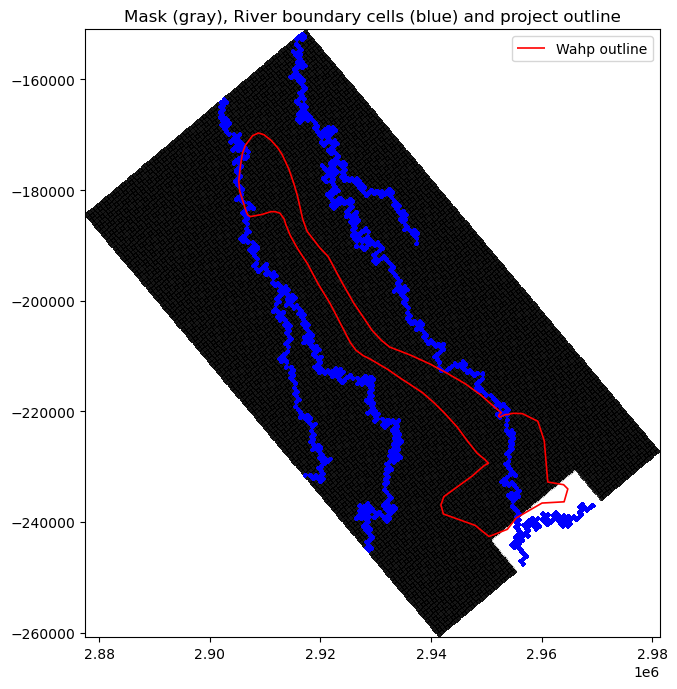

In [16]:
rows = np.arange(141, 152)
cols = np.arange(29, 59)
mask = np.zeros((nrows, ncols), dtype=int)
mask[np.ix_(rows - 1, cols - 1)] = 1

# if add second mask define and uncomment the merge line below:
r2 = np.arange(80,108)
c2 = np.arange(40, 55)
mask2 = np.zeros((nrows, ncols), dtype=int)
mask2[np.ix_(r2 - 1, c2 - 1)] = 1      # convert to 0-based Python index 
#mask = (mask | mask2).astype(int) # merge

# ----------------- outline shapefile (same CRS caveat) ---------------
outline_fp = os.path.join(
    "..", "..", "..", "gis", "input_shps", "wahp", "wahp_outline_full.shp"
)
wahp_outline = gpd.read_file(outline_fp)
if wahp_outline.crs is None:
    wahp_outline.set_crs(gwf.modelgrid.crs, inplace=True)

# ----------------- map view -----------------------------------------
fig, ax = plt.subplots(figsize=(8, 7))
mv = flopy.plot.PlotMapView(model=gwf, ax=ax)

# base array
mv.plot_array(mask, cmap="gray", alpha=0.7)

# **Flopy way** to draw the river‐package cells
mv.plot_bc(package=gwf.riv, color="blue", lw=0.8, label="River package")

# (optional) drains in green, wells in red, etc.
# mv.plot_bc(package=gwf.drn, color="green", lw=0.8, label="Drain package")
# mv.plot_bc(package=gwf.wel, color="red",  marker="o", ms=3, label="Wells")

# outline
wahp_outline.boundary.plot(ax=ax, color="red", linewidth=1.2, label="Wahp outline")

ax.set_title("Mask (gray), River boundary cells (blue) and project outline")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


Layer 3 new anisotropy field  →  min=1.00e-04, max=1.00e-01


C:\Users\RHarmon\AppData\Local\Temp\ipykernel_103260\945098100.py:64: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler


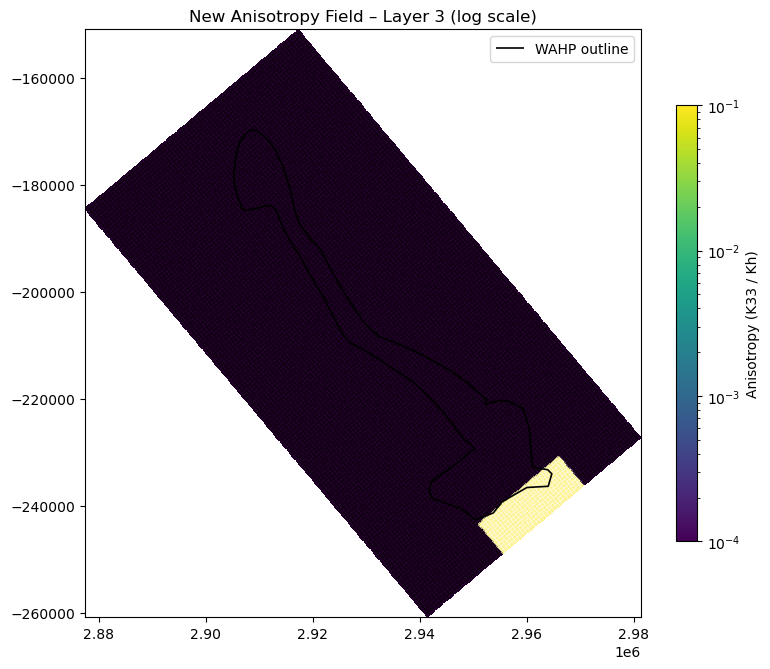

In [17]:
from matplotlib.colors import LogNorm

# ------------------------------------------------------------
# 2) Load anisotropy files, modify layer-3 array, plot & save
# ------------------------------------------------------------
aniso_files = sorted(
    [f for f in os.listdir(w_d) if f.startswith("npf_k33_")],
    key=lambda x: int(x.split("_")[2].split(".")[0].replace("layer", ""))
)

for file in aniso_files:
    ly = int(file.split("_")[2].split(".")[0].replace("layer", ""))  # zero-based layer #

    if ly != 3:
        continue  # only handle layer 3 in this loop

    # ---- read original anisotropy array ---------------------------------
    aniso = np.loadtxt(os.path.join(w_d, file))          # 2-D (nrow × ncol)

    # ---- apply mask: keep original where mask == 1, insert tiny value elsewhere
    aniso_mod = aniso.copy()
    aniso_mod[mask == 0] = chng_kv     # or whatever “very low” value you want

    print(f"Layer {ly} new anisotropy field  →  min={aniso_mod.min():.2e}, "
          f"max={aniso_mod.max():.2e}")

    # ---- Flopy map view plot --------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 7))
    mv = flopy.plot.PlotMapView(model=gwf, layer=ly, ax=ax)

    # (a) modified anisotropy
    mv.plot_array(
        aniso_mod,
        cmap="viridis",
        norm=LogNorm(vmin=aniso_mod.min(), vmax=aniso_mod.max()),
        alpha=0.9,
    )

    # (b) mask overlay
    mv.plot_array(mask, cmap="gray", alpha=0.3)

    # (c) river-package cells
    mv.plot_bc(package=gwf.riv, color="blue", lw=0.8, label="River package")

    # (d) outline shapefile
    outline_fp = os.path.join(
        "..", "..", "..", "gis", "input_shps", "wahp", "wahp_outline_full.shp"
    )
    wahp_outline = gpd.read_file(outline_fp)


    wahp_outline.boundary.plot(ax=ax, color="black", linewidth=1.2, label="WAHP outline")

    # ----- final touches --------------------------------------------------
    ax.set_title("New Anisotropy Field – Layer 3 (log scale)")
    cbar = plt.colorbar(
        plt.cm.ScalarMappable(
            norm=LogNorm(vmin=aniso_mod.min(), vmax=aniso_mod.max()), cmap="viridis"
        ),
        ax=ax,
        shrink=0.7,
        label="Anisotropy (K33 / Kh)",
    )
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # ---- overwrite the original text file with modified values ----------
    np.savetxt(os.path.join(w_d, file), aniso_mod, fmt="%.12f")


now modify .nam to remove recharge and ghb package and also modify npf to add save_specific discharge flag for vector plot:


now rerun model and cross your fingers it runs:

In [18]:
pyemu.utils.run("mf6",cwd=w_d)

mf6.exe


call plotting figures:

Layer 3 new anisotropy field  →  min=1.00e-03, max=1.00e-01


e:\projects\nddwr\NDDWR.C001.ASR-GW\models\wahp\notebooks\notebook_plotting.py:107: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler


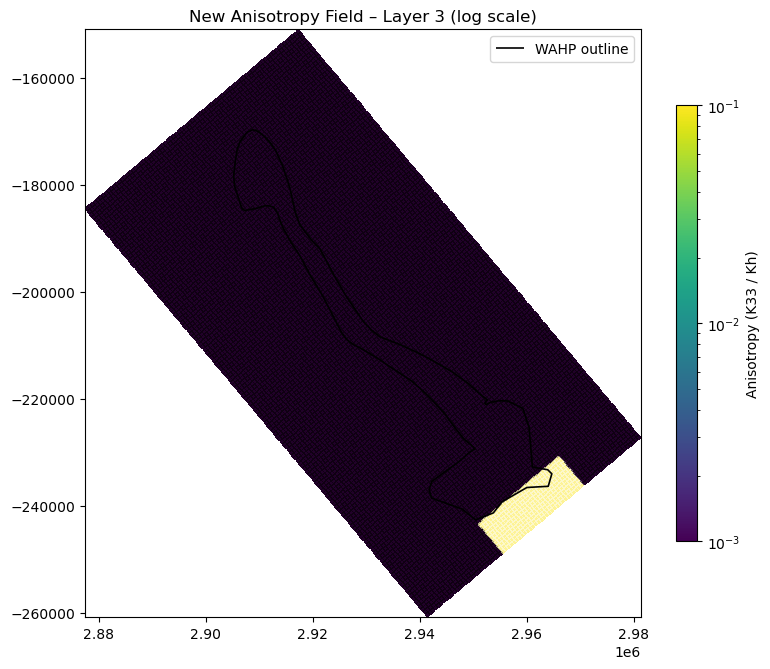

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package riv...
    loading package oc...
    loading package obs...
  loading solution package wahp...
saved → test_case_kv_1e-4\fig_params\vk_layer_01.png
saved → test_case_kv_1e-4\fig_params\vk_layer_02.png
saved → test_case_kv_1e-4\fig_params\vk_layer_03.png
saved → test_case_kv_1e-4\fig_params\vk_layer_04.png
saved → test_case_kv_1e-4\fig_params\vk_layer_05.png
saved → test_case_kv_1e-4\fig_params\vk_layer_06.png
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package riv...
    loading package oc...
    loading package obs...
  loading solution package wahp...
saved → test_case_kv_1e-4\

e:\projects\nddwr\NDDWR.C001.ASR-GW\models\wahp\notebooks\notebook_plotting.py:413: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler


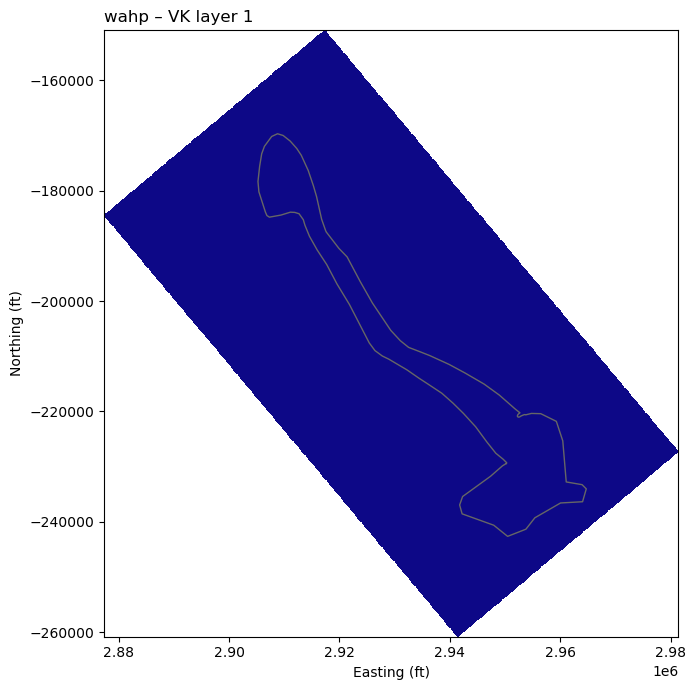

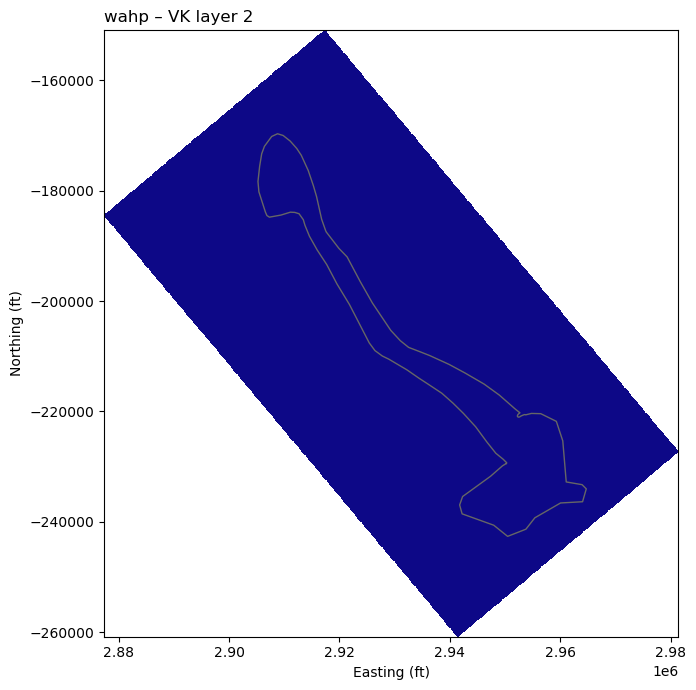

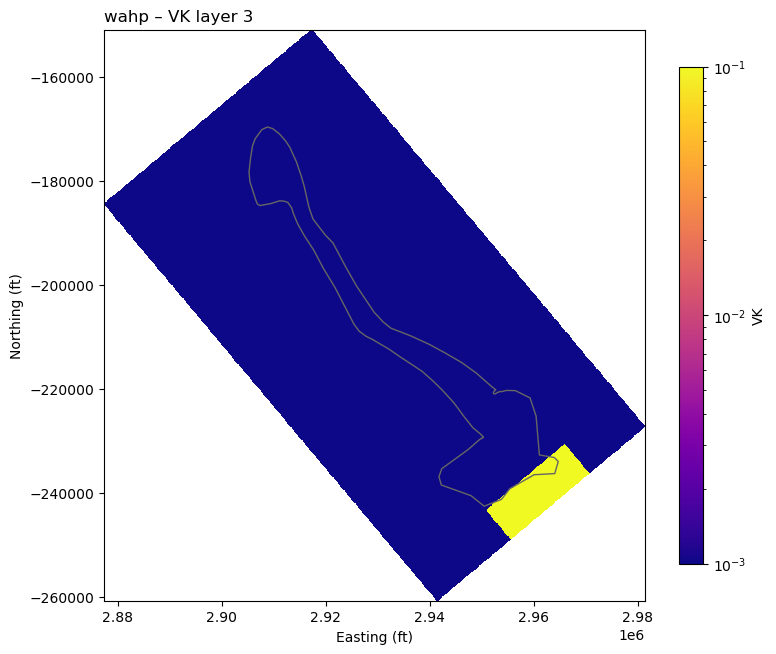

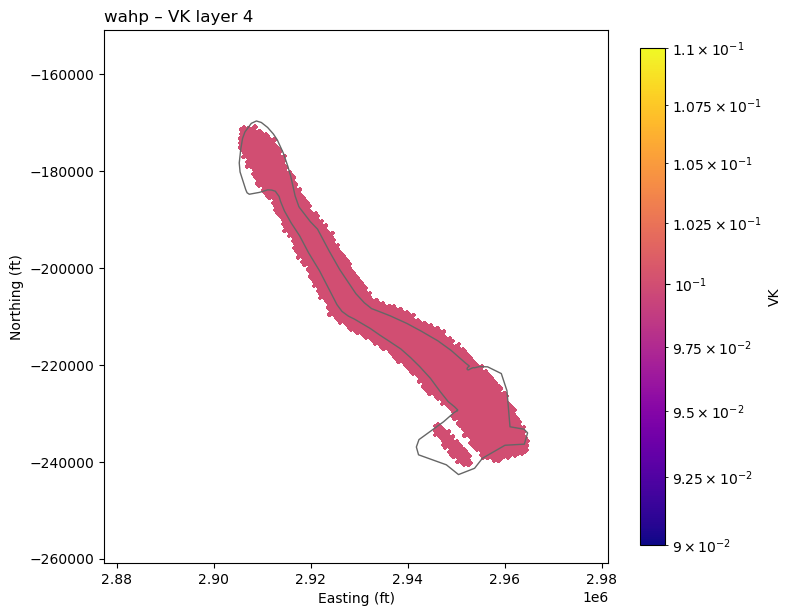

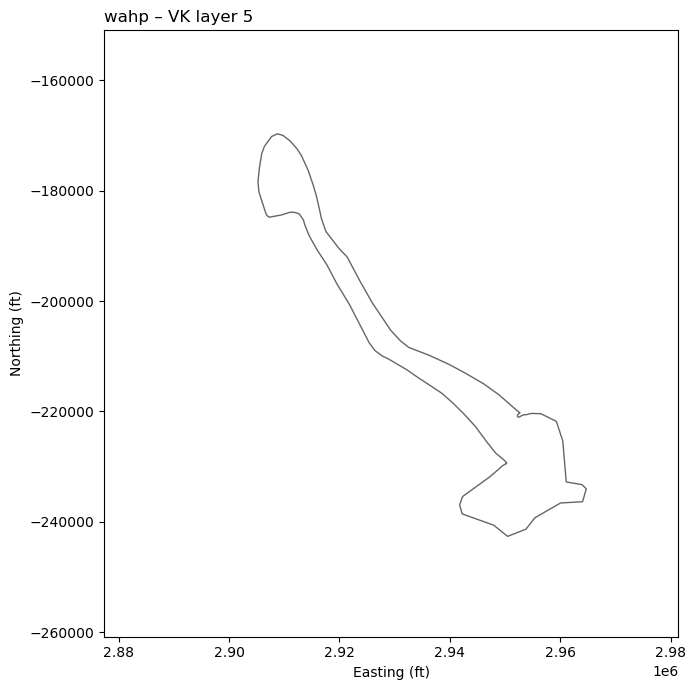

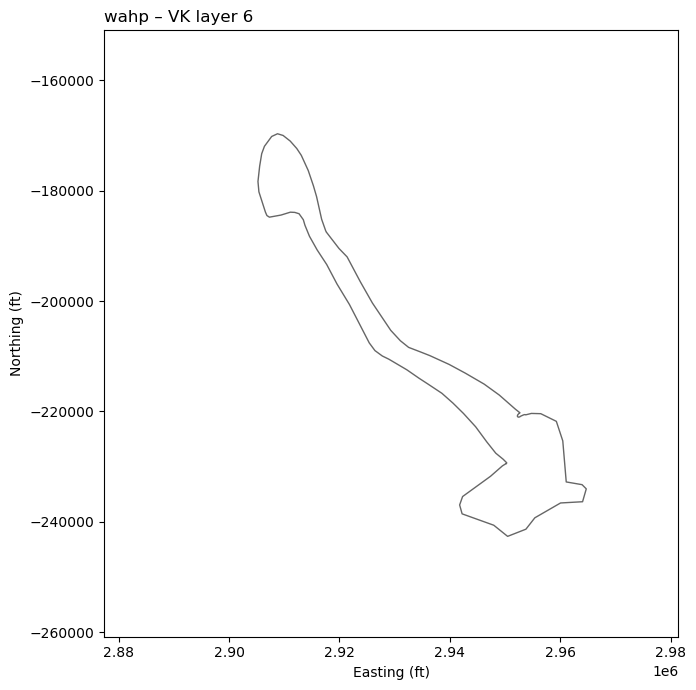

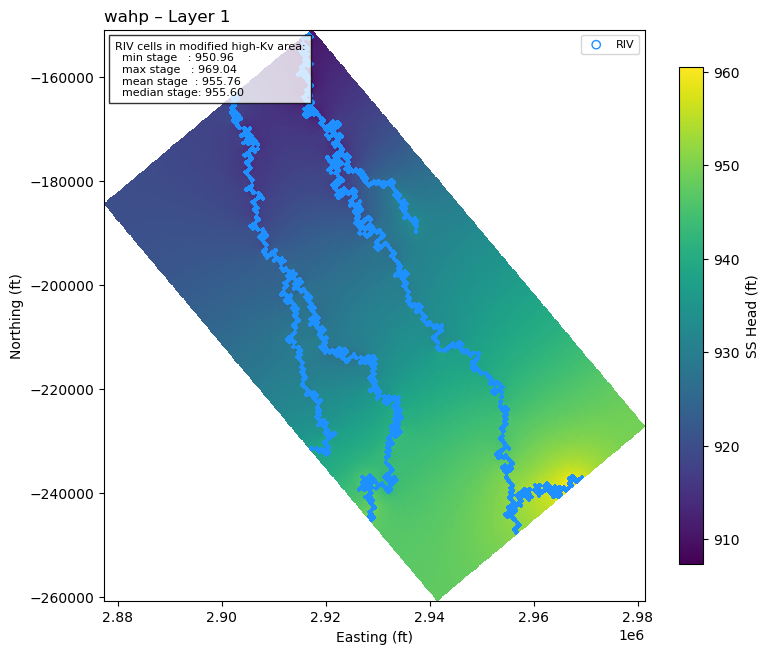

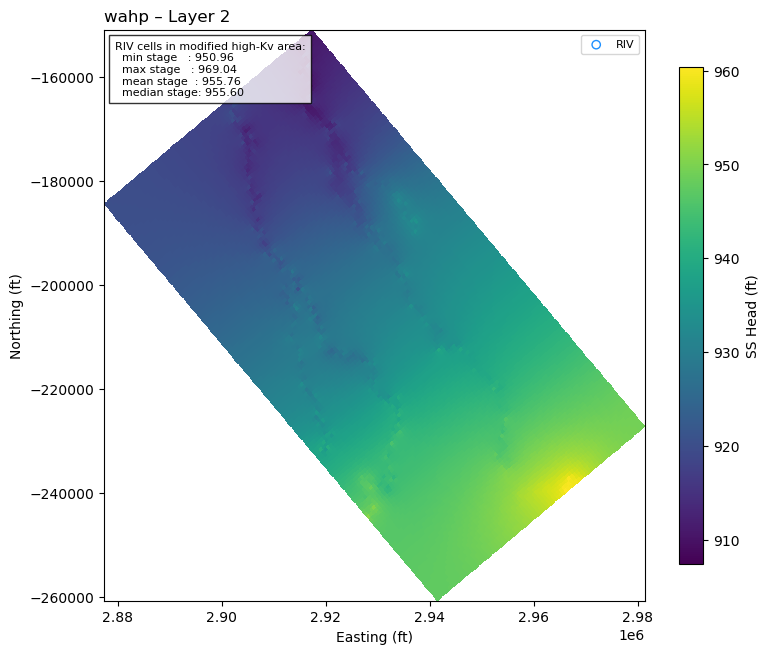

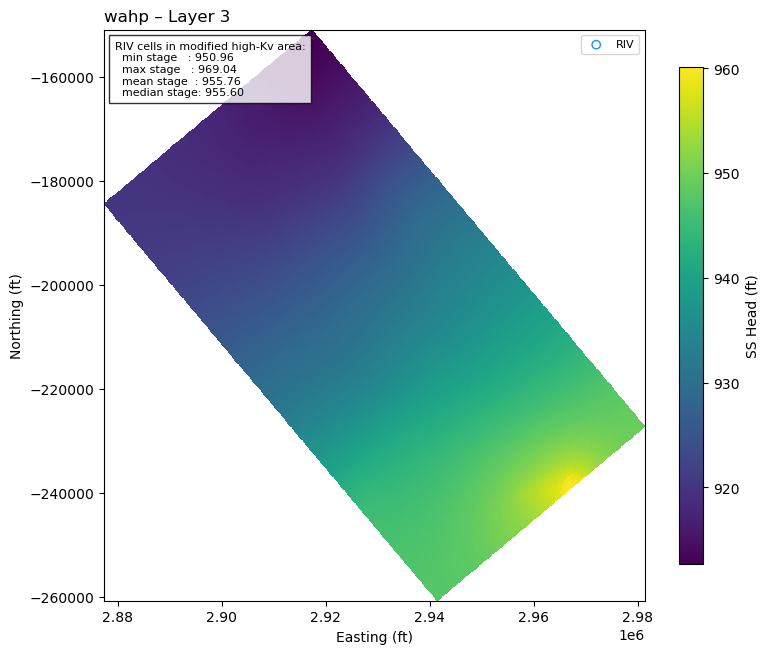

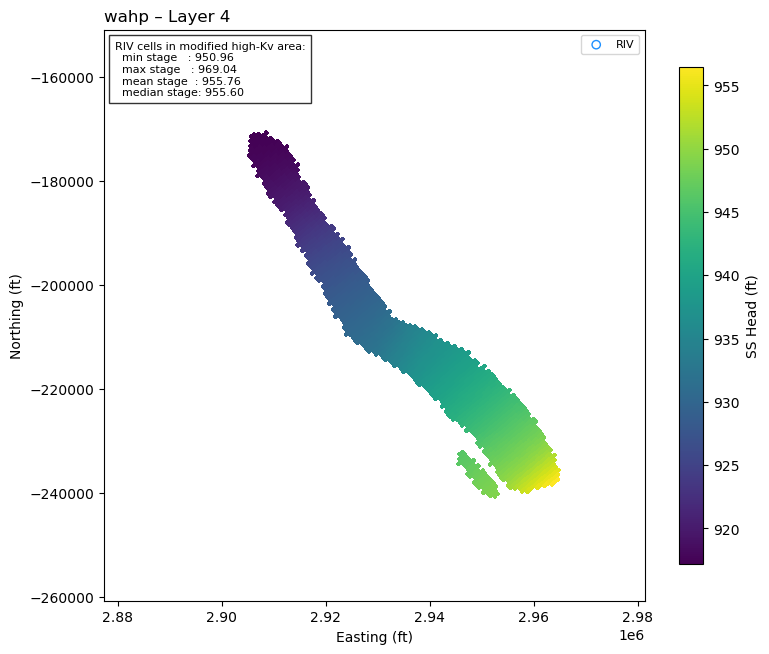

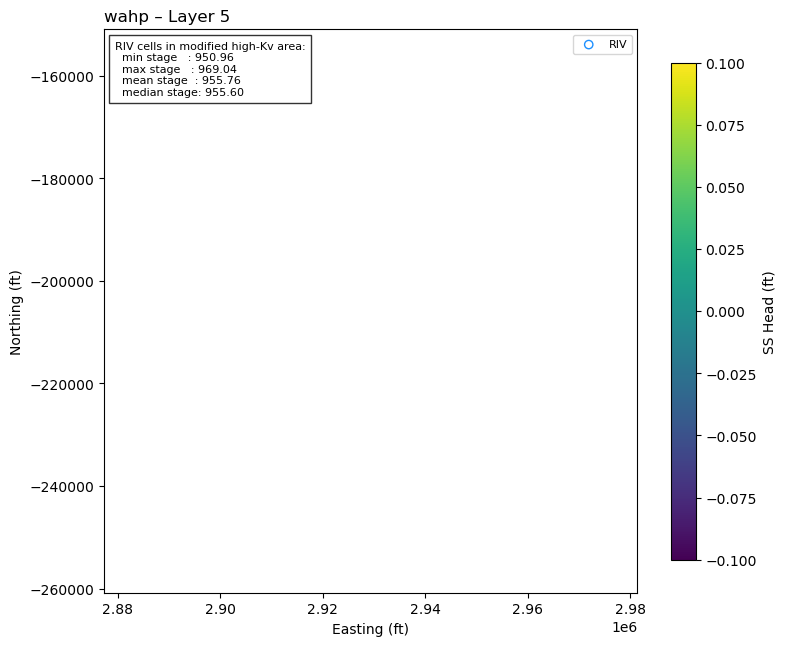

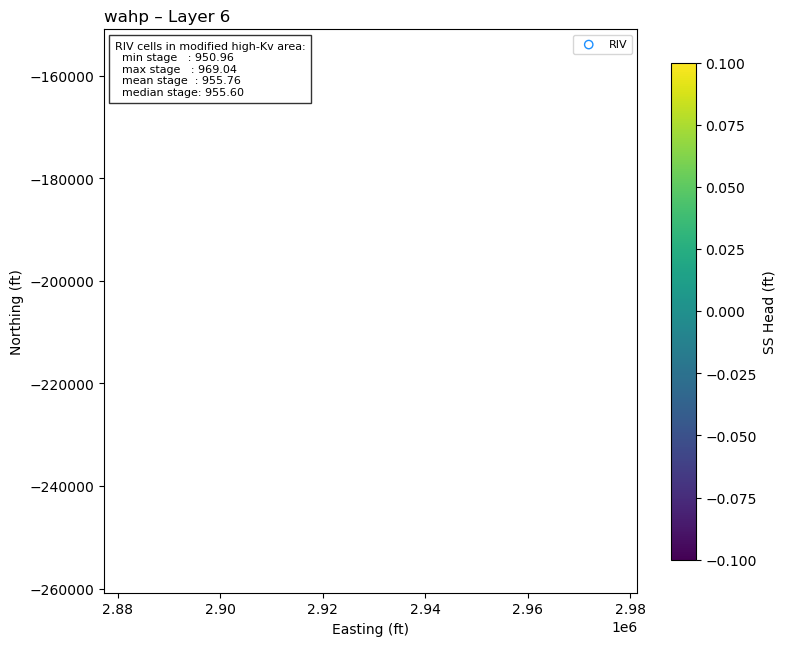

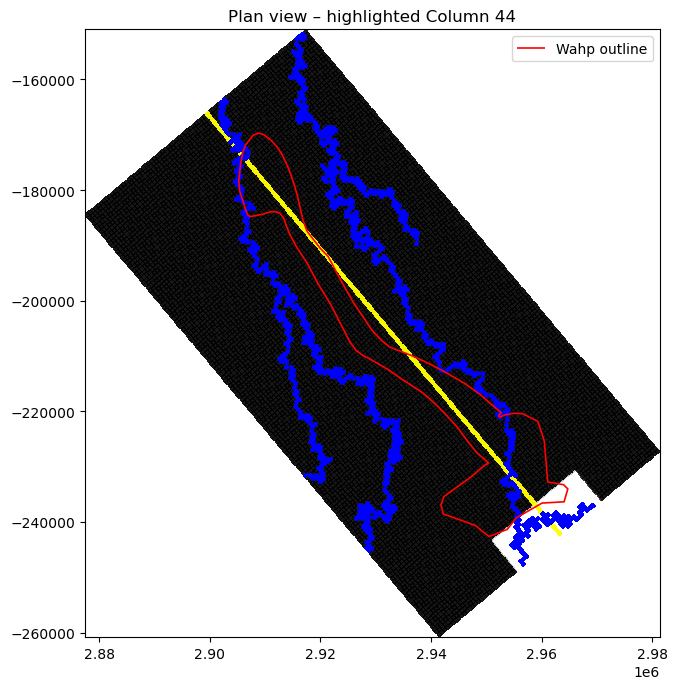

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    skipping package ic...
    skipping package npf...
    skipping package sto...
    loading package riv...
    loading package oc...
    skipping package obs...
    skipping package ims6...


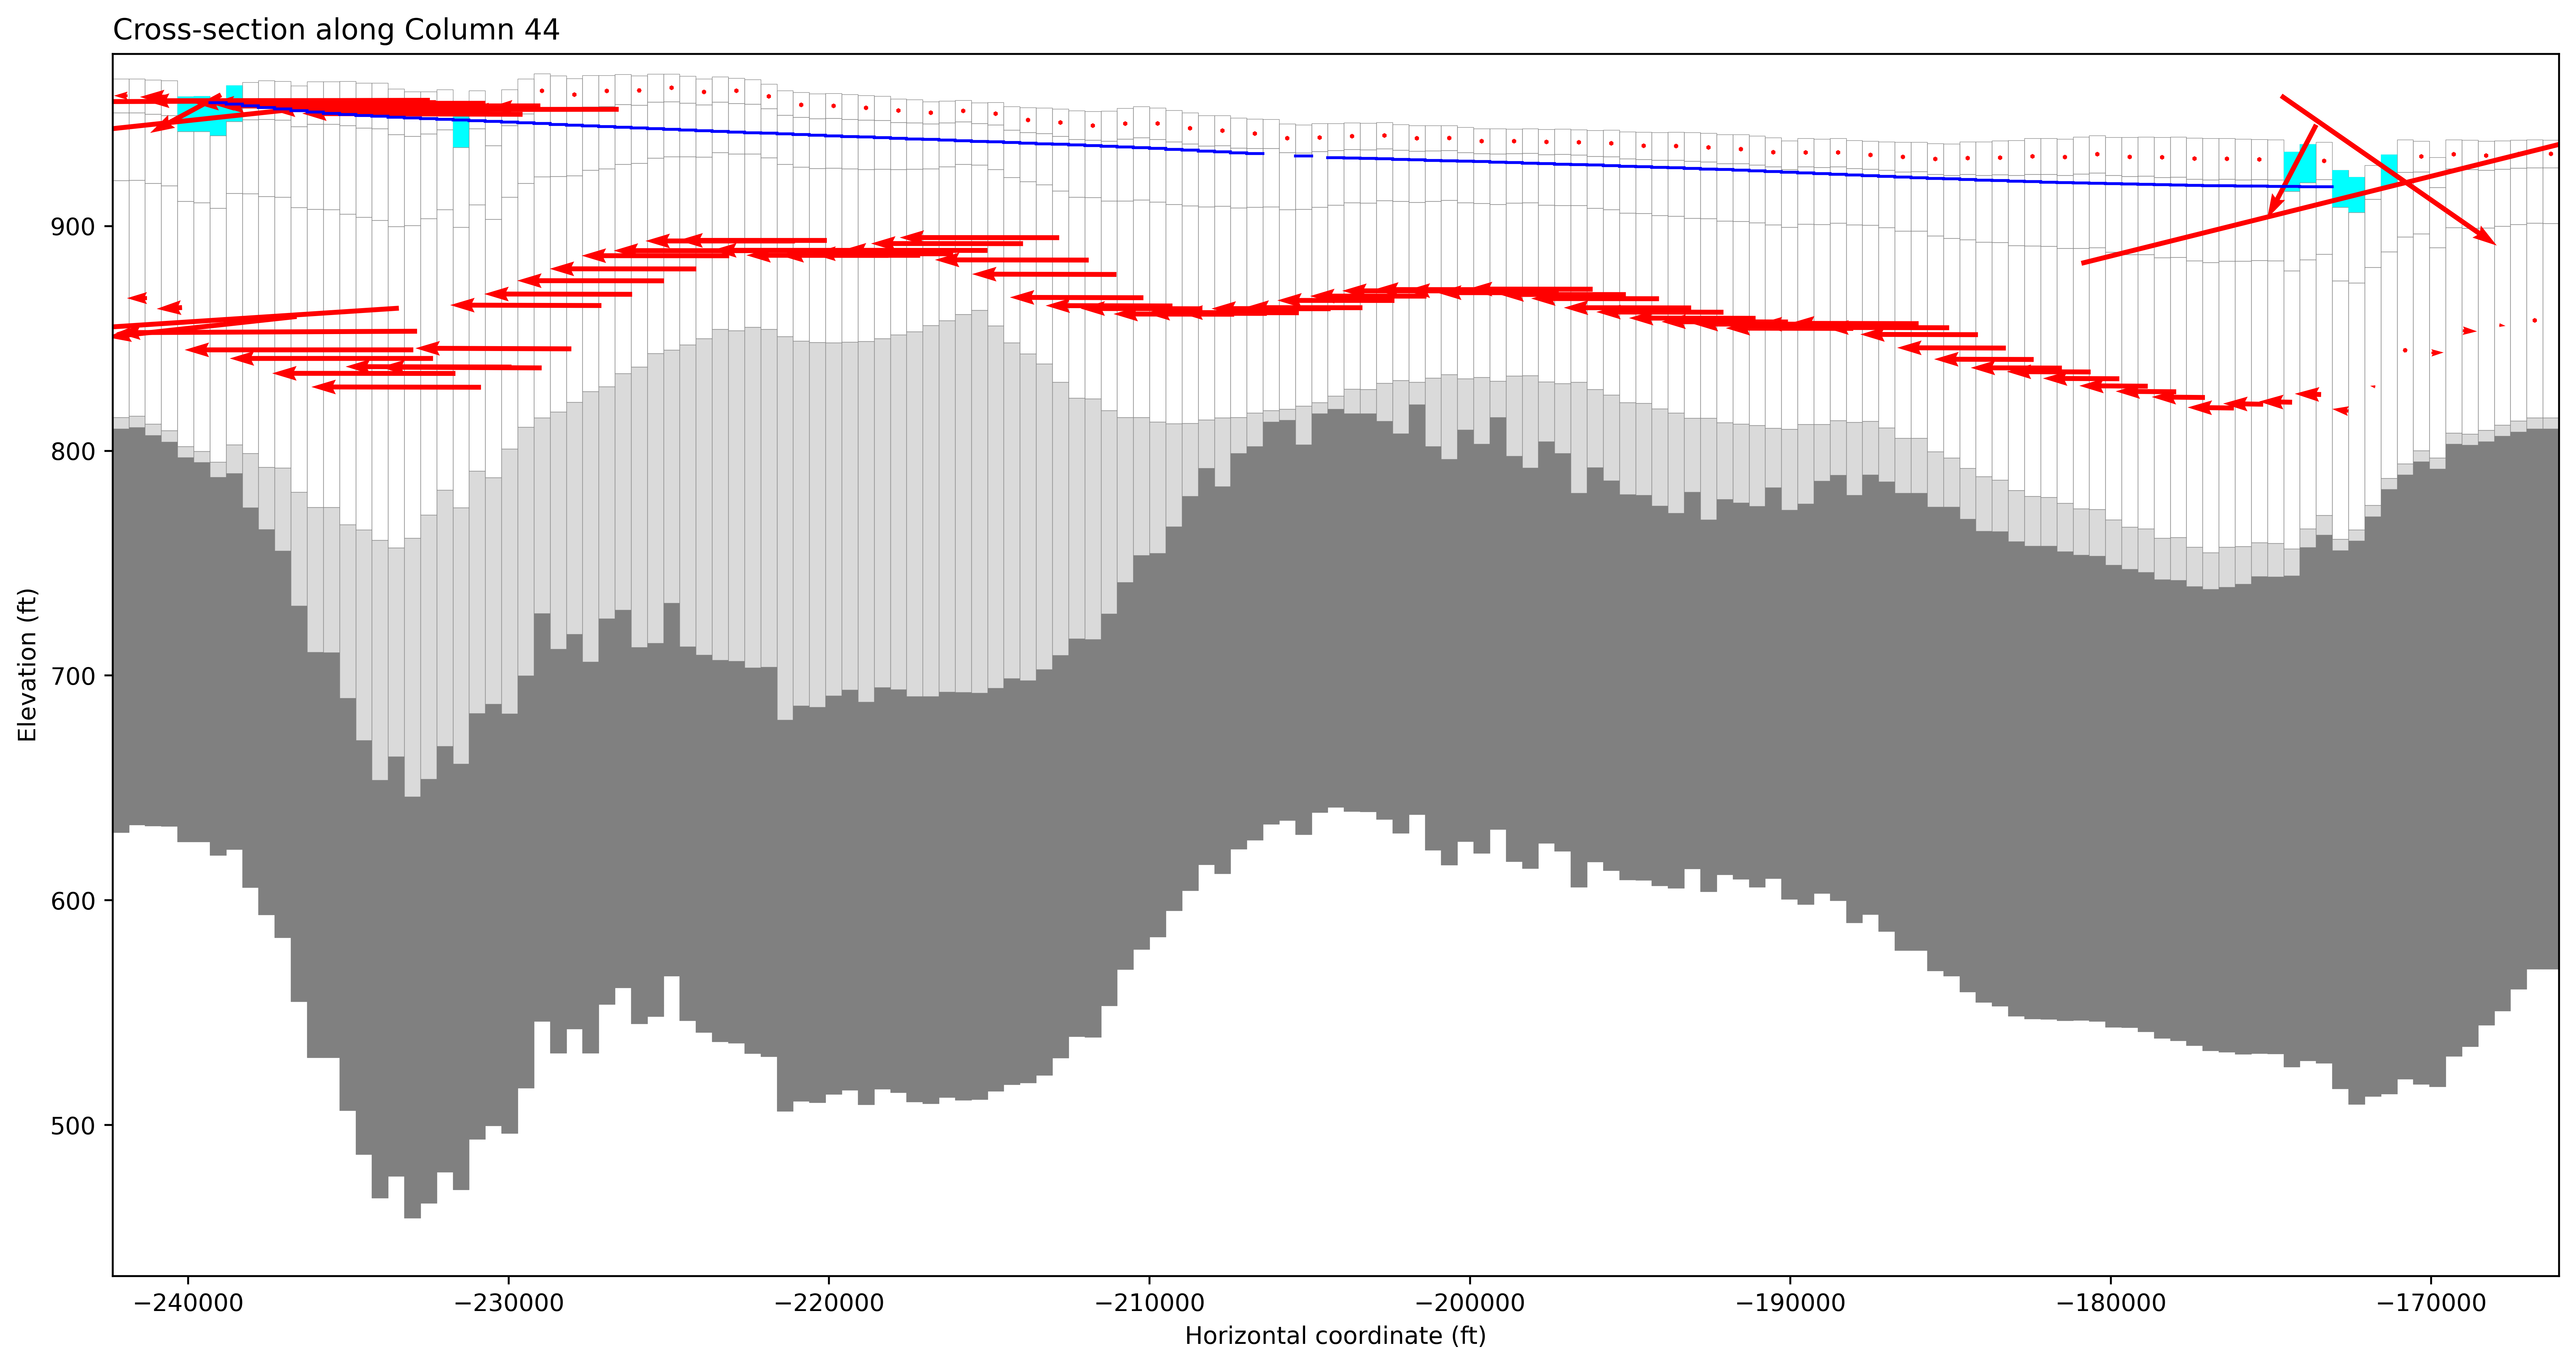

AttributeError: module 'notebook_plotting' has no attribute 'plot_obs_v_sim'

In [ ]:
# mf plotting:
nplt.plot_params_map_mel(w_d,partype="vk", logscale_hk = True)
nplt.plot_hds(w_d)
nplt.plot_plan_column(w_d, column=44)
nplt.plot_cross_section(model_ws=os.path.join(w_d),column=44)
nplt.plot_obs_v_sim(m_d)

# modpath plotting:
shutil.copy(os.path.join('..','..','..','bin','win','mp7.exe'), w_d)

nplt.clean_file_fmts(w_d)
# list of k,i,j to add particles:
kij = nplt.list_of_kij_to_add_particles(lys=np.arange(3,4),rows=np.arange(141, 152),cols=np.arange(29, 59))
# create particle groups with starting locations file:
particle_groups = nplt.set_particle_groups_strt_loc(gwf,w_d,kij)
# setup and run modpath simulation
mp, mpbas, mpsim, gwf = nplt.setup_modpath_sim(w_d, gwf, particle_groups)

nplt.plot_modpath(gwf, mpsim, w_d)


